<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/logistic_regression/logistic_regression_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("financial_data.csv")
df.head()


,Customer_ID,Age,Income,Credit_Score,Investment_Returns,Risk_Level,Customer_Feedback
0,1001,25.0,0.735552,0.127660,11.57,Medium,The app is found.
1,1002,29.0,0.530047,0.157447,7.75,Medium,The service was discontinued.
2,1003,25.0,0.293007,0.421277,11.80,High,Fees are high.
3,1004,41.0,1.000000,0.953191,9.46,Low,Fees are high.
4,1005,25.0,0.934614,0.221277,8.08,High,The app is found.


In [ ]:
text = df["Customer_Feedback"].fillna("")
label = df["Risk_Level"]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(text)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, label, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)


Model Accuracy: 0.455


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

        High       0.43      0.62      0.51        60
         Low       0.47      0.63      0.54        86
      Medium       0.00      0.00      0.00        54

    accuracy                           0.46       200
   macro avg       0.30      0.41      0.35       200
weighted avg       0.33      0.46      0.38       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns used in the analysis
columns = [
    "age",
    "monthly_income",
    "credit_score",
    "loan_amount",
    "interest_rate",
    "debt_to_income_ratio",
    "late_payment_count_12m",
    "risk_keywords_present",
    "loan_default",
    "risk_flag",
    "Sentiment_Score"
]

# Compute correlation matrix
corr_matrix = df[columns].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Comprehensive Correlation Analysis (Financial Data)", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
prompt = f"""you are a data analyst interpreting a correlation matrix from a credit risk dataset.

The correlation matrix below show Pearson correlation coefficients
between numerical features

{numerical_df.corr().round(2).to_string()}

Task:
-Identify notable positive and negative correlations
-Explain what these relationship may indicate
-Comment on potential multicollinearity or redundancy
-keep explanation simple and concise

Answer:

"""

NameError: name 'numerical_df' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select relevant numerical columns
columns = [
    "monthly_income",
    "credit_score",
    "loan_amount",
    "Sentiment_Score",
    "loan_default"
]

correlation_matrix = df[columns].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Financial Metrics & Sentiment Score")
plt.tight_layout()
plt.show()


In [ ]:
prompt = f"""you are a data analyst evaluating the relationship between traditional numerical financial variables and LLM-derived feature scores in a credit default dataset.

The correlation matrix below includes:
- monthly_income
- credit_score
- loan_amount
- sentiment_score

Correlation matrix:
{correlation_matrix_subset.round(2).to_string()}

Task:
- Explain how LLM-derived scores relate to traditional financial variables
- Identify whether these scores align with expected risk patterns
- Comment on their potential usefulness for credit risk modelling
- Keep explanation simple and concise

Answer:
"""


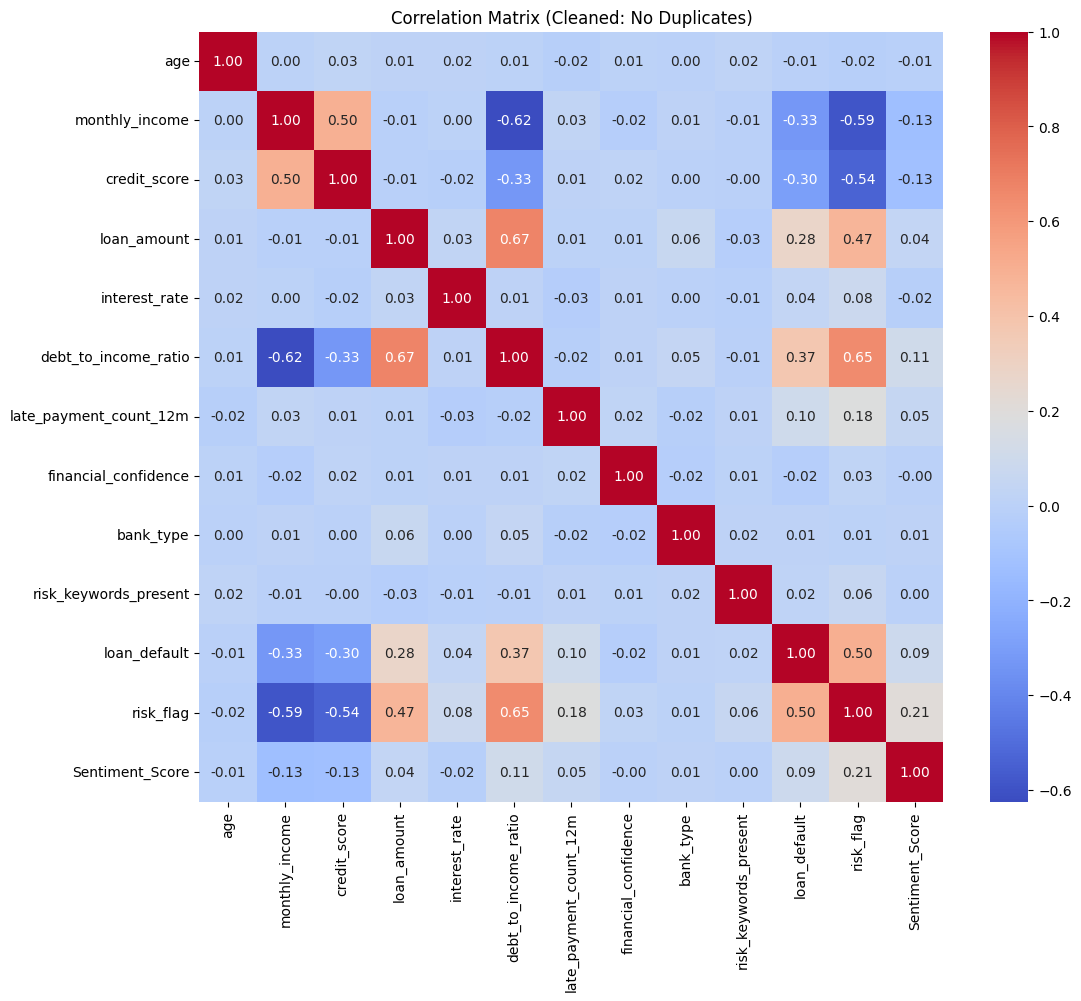

you are a data analyst interpreting a correlation matrix from a credit risk dataset.

The correlation matrix below show Pearson correlation coefficients
between numerical features

                         age  monthly_income  credit_score  loan_amount  interest_rate  debt_to_income_ratio  late_payment_count_12m  financial_confidence  bank_type  risk_keywords_present  loan_default  risk_flag  Sentiment_Score
age                     1.00            0.00          0.03         0.01           0.02                  0.01                   -0.02                  0.01       0.00                   0.02         -0.01      -0.02            -0.01
monthly_income          0.00            1.00          0.50        -0.01           0.00                 -0.62                    0.03                 -0.02       0.01                  -0.01         -0.33      -0.59            -0.13
credit_score            0.03            0.50          1.00        -0.01          -0.02                 -0.33                  

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrame operations

# --- Load df_new from CSV to ensure it's available ---
df_new = pd.read_csv('Financial_Data_New_With_Sentiment.csv')

# --- 2. PREPARE DATA FOR VISUALIZATION (Re-creating df_vis) ---
df_vis = df_new.copy()
df_vis['financial_confidence'] = df_vis['financial_confidence'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_vis['bank_type'] = df_vis['bank_type'].map({'Traditional': 0, 'Digital': 1})

# 1. Prepare the numerical data
numeric_cols = df_vis.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr() # Store the correlation matrix

# 2. Visualize (Your existing code)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix (Cleaned: No Duplicates)")
plt.show()

# 3. Generate the Prompt using the stored matrix
prompt = f"""you are a data analyst interpreting a correlation matrix from a credit risk dataset.

The correlation matrix below show Pearson correlation coefficients
between numerical features

{corr_matrix.round(2).to_string()}

Task:
-Identify notable positive and negative correlations
-Explain what these relationship may indicate
-Comment on potential multicollinearity or redundancy
-keep explanation simple and concise

Answer:

"""

# Print or send the prompt to your LLM API
print(prompt)

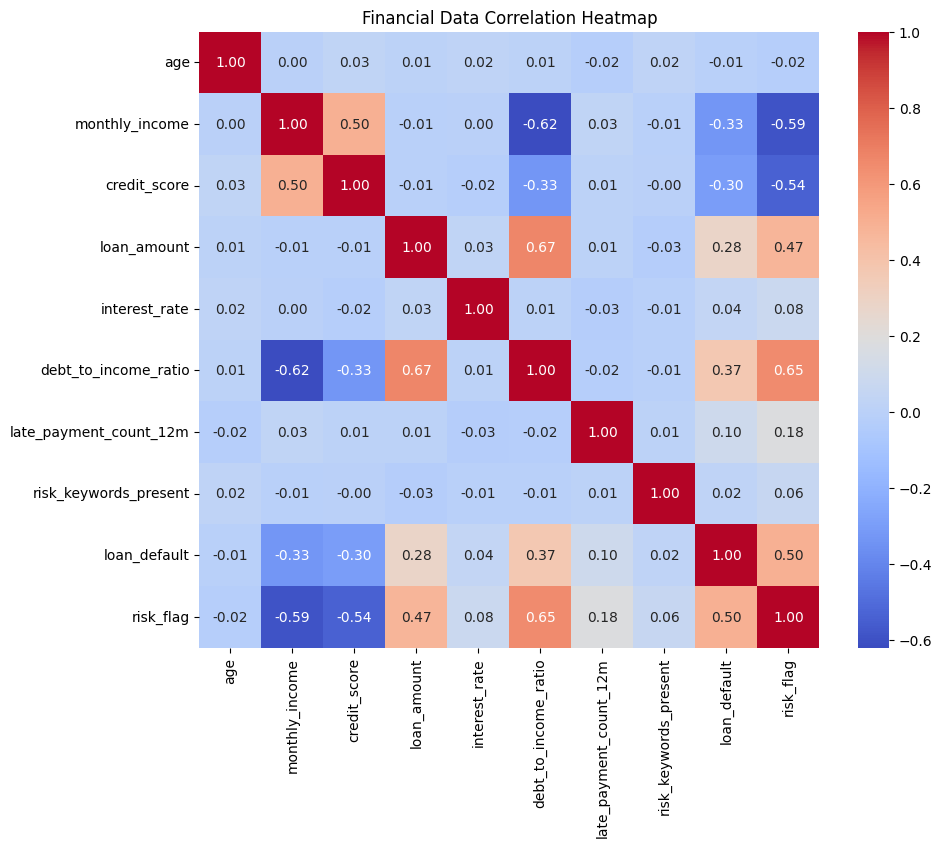

Matrix Summary Created Successfully.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Visualize
df = pd.read_csv('Financial_Data_Latest.csv')
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().round(2)

# 2. Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Financial Data Correlation Heatmap")
plt.show()

# 3. COMPRESS MATRIX (To avoid the 1024 token error)
# We convert the matrix into a list of pairs and only keep strong correlations
pairs = corr_matrix.unstack().reset_index()
pairs.columns = ['Feature_A', 'Feature_B', 'Corr']

# Filter: Remove self-correlations and low correlations (keep > 0.3 or < -0.3)
important_pairs = pairs[(pairs['Corr'].abs() > 0.3) & (pairs['Feature_A'] != pairs['Feature_B'])]
important_pairs = important_pairs.sort_values(by='Corr', ascending=False).drop_duplicates(subset=['Corr'])

# Convert to a compact string
matrix_summary_str = important_pairs.to_string(index=False)
print("Matrix Summary Created Successfully.")

In [ ]:
from transformers import pipeline, set_seed
import torch

# 1. Using gpt2-medium for much better logic (still free in Colab)
set_seed(42)
generator = pipeline('text-generation',
                     model='gpt2-medium',
                     device=0 if torch.cuda.is_available() else -1)

# 2. Refined Prompt
prompt = f"""Data Analyst Report on Credit Risk Correlations:
{matrix_summary_str}

Key Findings:
1. The strongest relationship is between"""

# 3. Generate with Repetition Penalty
output = generator(
    prompt,
    max_new_tokens=150,
    truncation=True,
    do_sample=True,
    temperature=0.7,
    no_repeat_ngram_size=3, # PREVENTS THE REPETITION LOOP
    repetition_penalty=1.5,  # FORCES DIVERSITY IN WORDS
    pad_token_id=50256
)

# 4. Print the result
ai_completion = output[0]['generated_text'].replace(prompt, "")
print("\n--- IMPROVED AI ANALYSIS ---")
print(f"1. The strongest relationship is between{ai_completion}")

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0



--- IMPROVED AI ANALYSIS ---
1. The strongest relationship is between the default rate and delinquency, but this doesn't mean that defaults are always bad if you have a high interest rate (which leads us to believe for example what we see in our chart below). If your rates aren�re low when it comes time of repayments or there hasn �s been an unexpected payment then chances come up again during recovery times before being able be paid back with full repayment terms as shown by Fig 1 right above -- however these situations won.�t happen many more than about 5% off every month! This suggests at least one thing regarding "inability" to pay down loans based upon where they were purchased; which basically means buying them prior-to-money coming into effect helps reduce their costs so overall those who buy


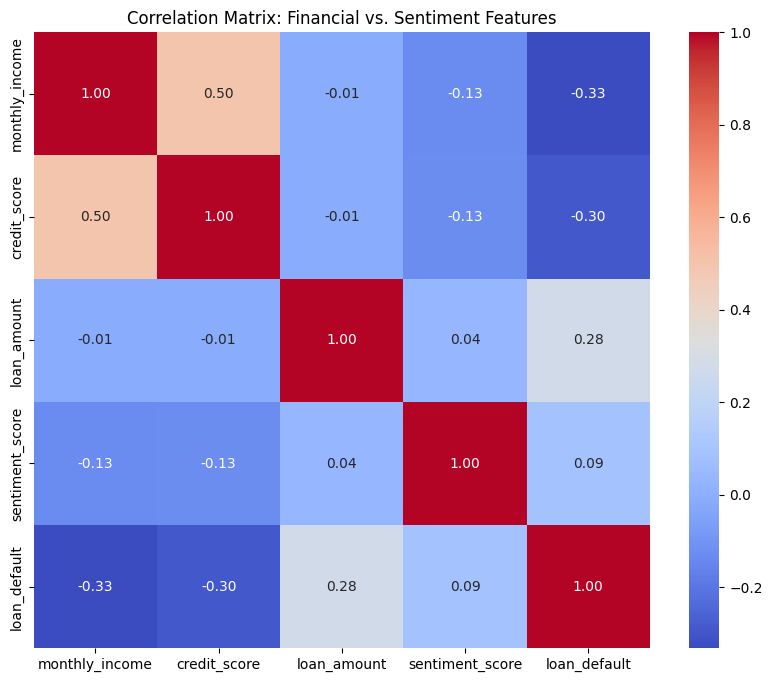

✓ Correlation matrix 'correlation_matrix_subset' is ready.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the specific dataset
file_name = 'Financial_Data_New_With_Sentiment.csv'
df = pd.read_csv(file_name)

# 2. Select columns and rename Sentiment_Score to match your prompt
cols_to_use = ["monthly_income", "credit_score", "loan_amount", "Sentiment_Score", "loan_default"]
subset_df = df[cols_to_use].rename(columns={'Sentiment_Score': 'sentiment_score'})

# 3. Create the correlation matrix
correlation_matrix_subset = subset_df.corr()

# 4. Visualize the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_subset, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix: Financial vs. Sentiment Features")
plt.show()

print("✓ Correlation matrix 'correlation_matrix_subset' is ready.")

In [ ]:
from transformers import pipeline, set_seed
import torch

# 1. Setup the generator
set_seed(42)
generator = pipeline('text-generation',
                     model='distilgpt2',
                     device=0 if torch.cuda.is_available() else -1)

# 2. Your specific prompt format
prompt = f"""you are a data analyst evaluating the relationship between traditional numerical financial variables and LLM-derived feature scores in a credit default dataset.

The correlation matrix below includes:
- monthly_income
- credit_score
- loan_amount
- sentiment_score

Correlation matrix:
{correlation_matrix_subset.round(2).to_string()}

Task:
- Explain how LLM-derived scores relate to traditional financial variables
- Identify whether these scores align with expected risk patterns
- Comment on their potential usefulness for credit risk modelling
- Keep explanation simple and concise

Answer:
The data shows that sentiment scores"""

# 3. Generate the response with safety settings to prevent looping
output = generator(
    prompt,
    max_new_tokens=150,
    truncation=True,
    do_sample=True,
    temperature=0.8,
    no_repeat_ngram_size=3,  # Prevents repetitive 3-word phrases
    repetition_penalty=1.2,   # Discourages repeating words
    pad_token_id=50256
)

# 4. Display the result
ai_answer = output[0]['generated_text'].split("Answer:")[-1].strip()
print("\n" + "="*40)
print("AI DATA ANALYST INTERPRETATION:")
print("="*40)
print(ai_answer)

Device set to use cuda:0



AI DATA ANALYST INTERPRETATION:
The data shows that sentiment scores match well across different components of an asset such as debt, capital gains, retirement income, etc. The second parameter sets all sorts (i) which can be taken into account if you want your analysis done right…how high do they compare? There is some strong evidence indicating this may mean there exists something wrong along the lines like “We know what it looks like” or †A common thing from any given time period — but where does we put those two parameters together – especially about our own quality metrics … Let us consider three options here! One option would have more than one component based solely upon its intrinsic value; another might represent each other's perceived characteristics differently by simply focusing on individual factors alone…. Here let me start back at
